# **Prediksi Saham BBCA menggunakan LSTM**
# 0.Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import kagglehub, os, math
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, LSTM
from sklearn.metrics import mean_absolute_error

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1.Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muamkh/ihsgstockdata", output_dir="./dataset")

print("Path to dataset files:", path)

Path to dataset files: ./dataset


In [3]:
saham_df = pd.read_csv("dataset/DaftarSaham.csv")
saham_df[saham_df["Code"] == "BBCA"]

,Code,Name,ListingDate,Shares,ListingBoard,Sector,LastPrice,MarketCap,MinutesFirstAdded,MinutesLastUpdated,HourlyFirstAdded,HourlyLastUpdated,DailyFirstAdded,DailyLastUpdated
82,BBCA,Bank Central Asia Tbk.,2000-05-31,1.220423e+11,Utama,Financials,8300.0,1.012951e+15,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2001-04-16,2023-01-06


In [4]:
bbca_df = pd.read_csv("dataset/daily/BBCA.csv")
bbca_df["timestamp"] = pd.to_datetime(bbca_df["timestamp"])
bbca_df.set_index("timestamp")

,open,low,high,close,volume
timestamp,,,,,
2001-04-16,175,175,180,177,0
2001-04-17,175,175,180,177,0
2001-04-18,175,175,180,177,0
2001-04-19,175,175,180,177,0
2001-04-20,175,175,180,177,0
...,...,...,...,...,...
2023-01-02,8575,8500,8600,8550,10653900
2023-01-03,8550,8525,8600,8550,27399100
2023-01-04,8525,8350,8575,8350,90918800


# 2.Exploratory Data Analysis

In [5]:
bbca_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5670 entries, 0 to 5669
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  5670 non-null   datetime64[us]
 1   open       5670 non-null   int64         
 2   low        5670 non-null   int64         
 3   high       5670 non-null   int64         
 4   close      5670 non-null   int64         
 5   volume     5670 non-null   int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 265.9 KB


In [6]:
bbca_df.describe()

,timestamp,open,low,high,close,volume
count,5670,5670.000000,5670.000000,5670.000000,5670.000000,5.670000e+03
mean,2012-02-25 12:00:00,2418.109877,2393.385538,2442.639506,2418.603175,8.919048e+07
min,2001-04-16 00:00:00,175.000000,175.000000,177.000000,177.000000,0.000000e+00
25%,2006-09-20 06:00:00,460.000000,455.000000,467.000000,460.500000,2.719000e+07
50%,2012-02-25 12:00:00,1585.000000,1570.000000,1600.000000,1585.000000,6.161450e+07
75%,2017-08-01 18:00:00,3743.750000,3715.000000,3765.000000,3740.000000,1.045481e+08
max,2023-01-06 00:00:00,9050.000000,8975.000000,9400.000000,9300.000000,1.949960e+09
std,NaN,2379.071545,2357.118837,2400.150856,2378.798150,1.274925e+08


In [7]:
miss_val = bbca_df.isna().sum()
persentase = ((miss_val / len(bbca_df)) * 100).round(2)

missing = pd.DataFrame({
    "Missing Value": miss_val,
    "Persentase": persentase
})

missing

,Missing Value,Persentase
timestamp,0,0.0
open,0,0.0
low,0,0.0
high,0,0.0
close,0,0.0
volume,0,0.0


In [8]:
duplicated = bbca_df.duplicated().sum()
duplicated

np.int64(0)

In [9]:
features = ["open", "low", "high", "close", "volume"]

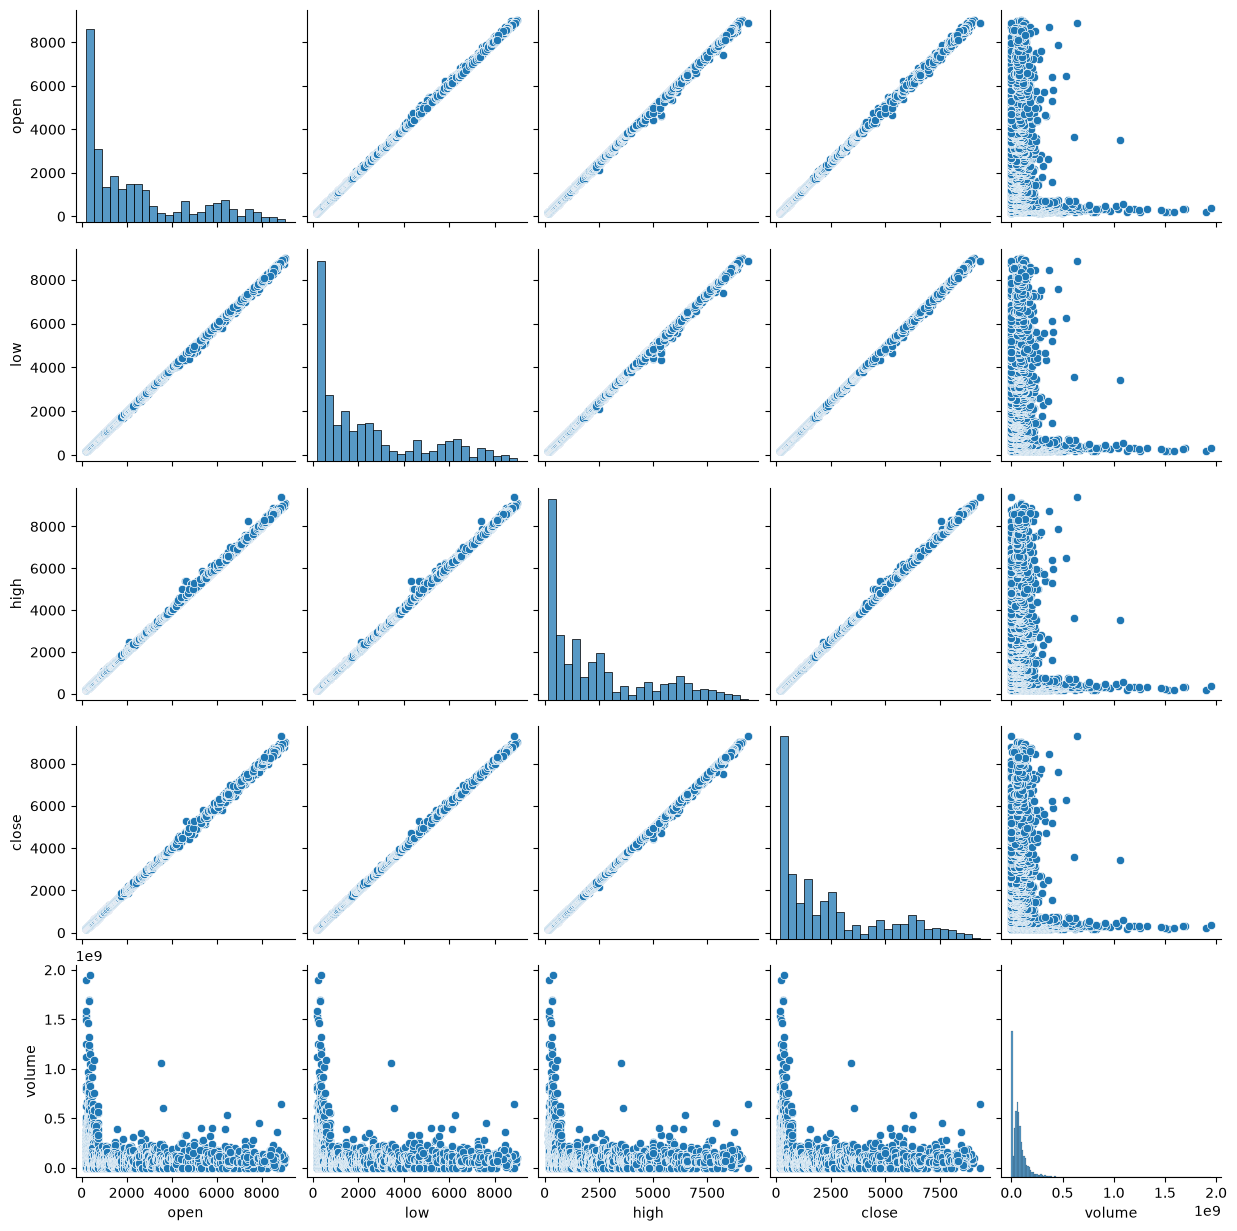

In [10]:
sns.pairplot(bbca_df[features])

Text(0.5, 1.0, 'Corrleation Matrix')

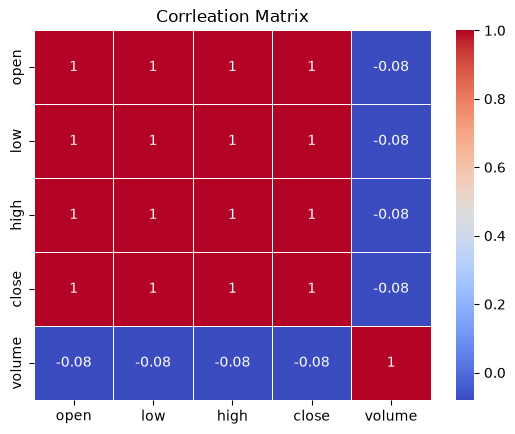

In [11]:
sns.heatmap(
    bbca_df[features].corr().round(2),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Corrleation Matrix")

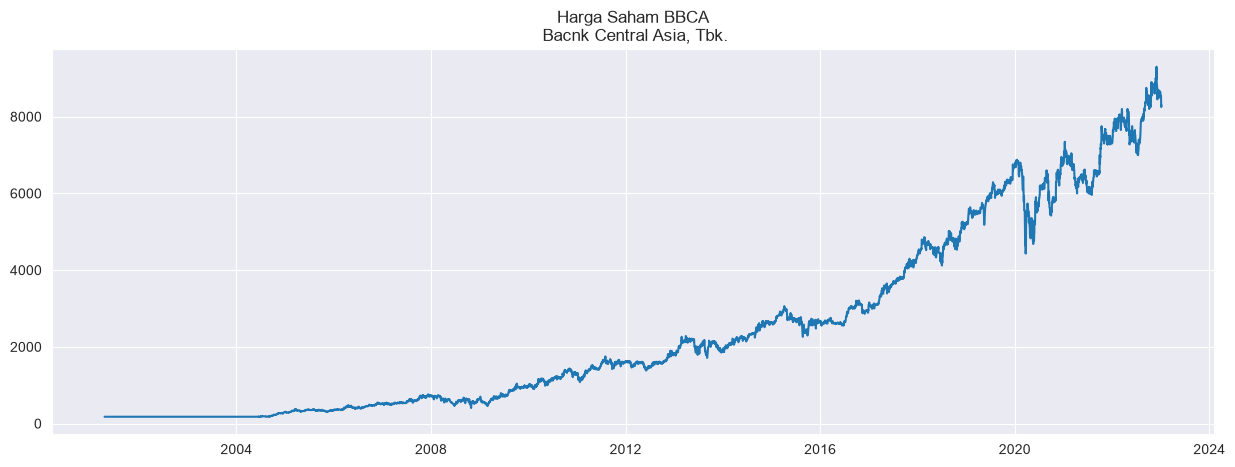

In [12]:
plt.figure(figsize=(15, 5))
sns.set_style("darkgrid")   
plt.plot(bbca_df["timestamp"], bbca_df["close"])
plt.title("Harga Saham BBCA\n Bacnk Central Asia, Tbk.")
plt.show()

# 3.Data Preprocessing

In [13]:
train_size = int(len(bbca_df) * 0.8)
train, test = bbca_df[:train_size], bbca_df[train_size:]

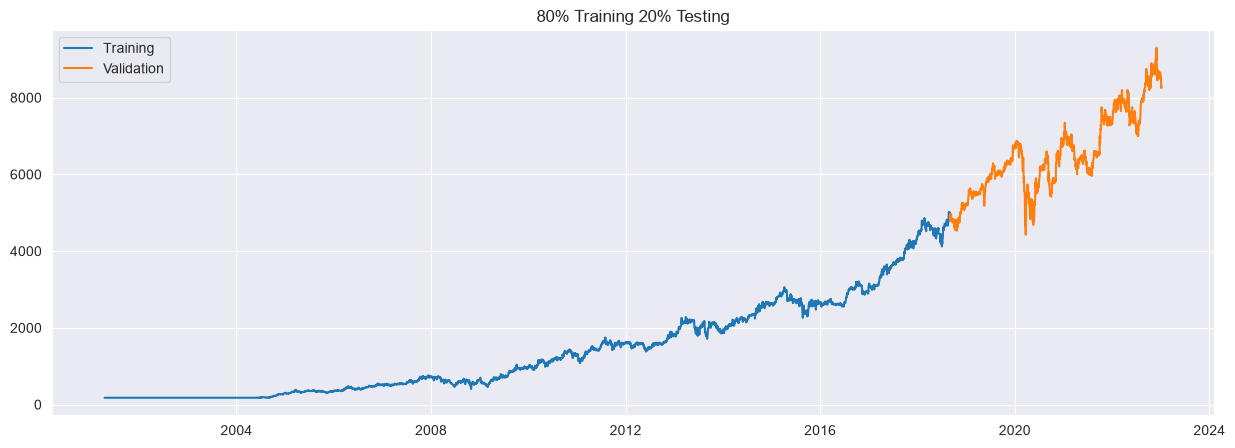

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(train["timestamp"], train["close"], label="Training")
plt.plot(test["timestamp"], test["close"], label="Validation")
plt.legend(labels=["Training", "Validation"])
plt.title("80% Training 20% Testing")
plt.show()

In [15]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[["close"]])
test_scaled = scaler.transform(test[["close"]])

In [16]:
train_scaled

array([[0.        ],
       [0.        ],
       [0.        ],
       ...,
       [1.        ],
       [0.98863167],
       [0.98759818]], shape=(4536, 1))

In [17]:
train_scaled = pd.DataFrame(train_scaled, columns=scaler.get_feature_names_out())
train_scaled

,close
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
4531,0.995866
4532,0.988632
4533,1.000000
4534,0.988632


In [18]:
test_scaled

array([[0.9865647 ],
       [0.95556015],
       [0.98449773],
       ...,
       [1.68933444],
       [1.66866474],
       [1.67899959]], shape=(1134, 1))

In [19]:
test_scaled = pd.DataFrame(test_scaled, columns=scaler.get_feature_names_out())
test_scaled

,close
0,0.986565
1,0.955560
2,0.984498
3,0.990699
4,0.986565
...,...
1129,1.730674
1130,1.730674
1131,1.689334
1132,1.668665


In [20]:
def windowed_dataset(dataset, window_size, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(dataset)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.map(lambda w: (w[:-1], w[-1:]))

    return ds.batch(batch_size).prefetch(1)

In [21]:
train_set = windowed_dataset(train_scaled, window_size=1, batch_size=100)
test_set = windowed_dataset(test_scaled, window_size=1, batch_size=100)

# 4.Modeling

In [22]:
window_size = 1
len_features = 1

model = Sequential()
model.add(LSTM(100, input_shape=(window_size, len_features), return_sequences=True))
model.add(LSTM(50))
model.add(Dense(25, activation="relu"))
model.add(Dense(len_features))

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
class Callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("val_mae") is not None and logs.get("val_mae") < 0.015:
            self.model.stop_training = True

In [24]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, metrics=["mae"], loss=tf.keras.losses.Huber())
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    train_set,
    validation_data=test_set, 
    epochs=500,
    shuffle=False, 
    callbacks=[Callback()]
)

Epoch 1/500
     37/Unknown 6s 4ms/step - loss: 0.0234 - mae: 0.1508   

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0593 - mae: 0.2414 - val_loss: 0.7731 - val_mae: 1.2729
Epoch 2/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0540 - mae: 0.2273 - val_loss: 0.7444 - val_mae: 1.2439
Epoch 3/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0490 - mae: 0.2157 - val_loss: 0.7131 - val_mae: 1.2123
Epoch 4/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0442 - mae: 0.2058 - val_loss: 0.6789 - val_mae: 1.1777
Epoch 5/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0397 - mae: 0.1982 - val_loss: 0.6406 - val_mae: 1.1387
Epoch 6/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0354 - mae: 0.1923 - val_loss: 0.6002 - val_mae: 1.0970
Epoch 7/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0317 - mae: 0.1883 - val_loss: 0.5559 - val_mae: 1.0508
Epoch 8/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0284 - mae: 0.1840 - val_loss: 0.5123 - val_mae: 1.0046
Epoch 9/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0258 - mae: 0.

# 5.Evaluation

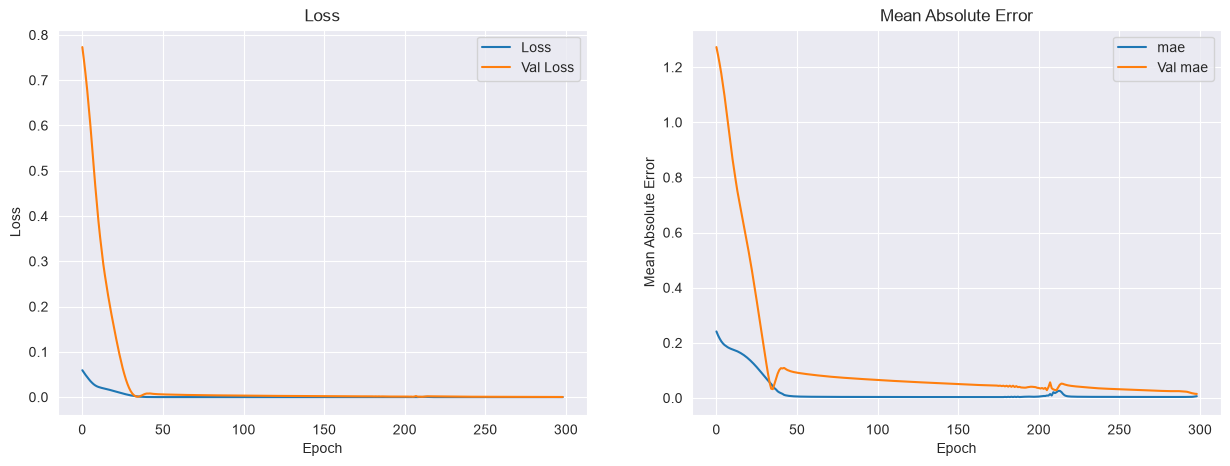

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history.history["loss"]) 
ax1.plot(history.history["val_loss"])
ax1.legend(["Loss", "Val Loss"]) 
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")

# MAE
ax2.plot(history.history["mae"])
ax2.plot(history.history["val_mae"])
ax2.legend(["mae", "Val mae"])
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean Absolute Error")
ax2.set_title("Mean Absolute Error")
plt.show()

In [33]:
pred = model.predict(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [34]:
pred

array([[0.98700297],
       [0.9557154 ],
       [0.98491263],
       ...,
       [1.7326374 ],
       [1.6917377 ],
       [1.671289  ]], shape=(1133, 1), dtype=float32)

In [35]:
# Ubah menjadi 1D
pred_scaled = pred.reshape(-1, 1)

# Ambil aktual dari test_set
actual_scaled = np.concatenate([y.numpy().reshape(-1, 1) for _, y in test_set])

# Inverse transform ke harga asli
pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(actual_scaled)

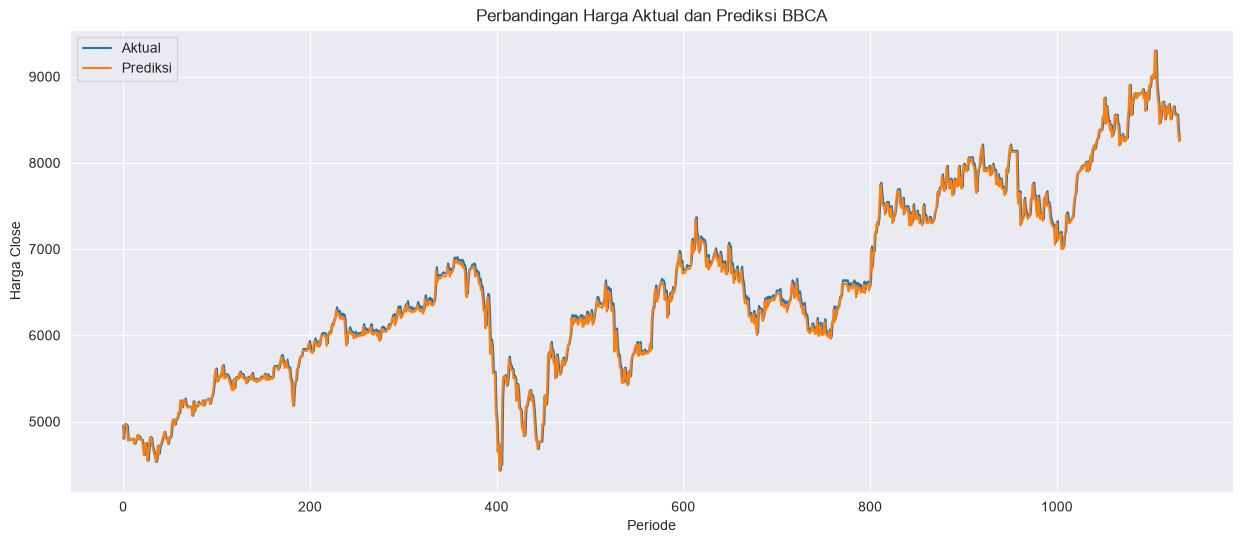

In [38]:
# Plot
plt.figure(figsize=(15, 6))

plt.plot(pred, label="Aktual")
plt.plot(actual, label="Prediksi")
plt.title("Perbandingan Harga Aktual dan Prediksi BBCA")
plt.xlabel("Periode")
plt.ylabel("Harga Close")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
model.save("bbca_forecast_model.h5")